# _Context si obiective_:<br>
&nbsp;&nbsp;Problema abordata consta in predicctia bolilor cardiovasculare pe baza
unor indicatori clinici si demografici ai pacientilor. Intrucat bolile de inima reprezinta principala cauza de deces la nivel global, un model de Machine Learning capabil sa identifice pacientii cu risc ridicat poate sprijini deciziile medicale preventive si salva vieti.

### _Variabilele Proiectului_:<br>
&nbsp;  &nbsp;Variabile tinta (output) - clasificare binara<br>
&nbsp;&nbsp;&nbsp;1 : Prezenta bolii de inima<br>
&nbsp;&nbsp;&nbsp;0 : Absenta bolii (normal)\n<br>
&nbsp; &nbsp;Variabile de intrare : varsta, sexul, tipul durerii in piept (ChestPainType), tensiunea arteriala (RestingBP), colesterolul, glicemia (FastingBS), rezultatele ECG, ritmul cardiac maxim (MaxHR), angina indusa de efort

### _Motivatia alegerii_:<br>
&nbsp;&nbsp;Am ales aceasta problema datorita impactului social major si a 
disponibilitatii unui dataset echilibrat care permite utilizarea tehnicilor de xplicabilitare (SHAP), esentiale in domeniul medical.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import shap

df = pd.read_csv('../data/heart.csv')

**EDA**

In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  1

In [4]:
#tratam aniomaliile din date
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())

C:\Users\Diana\AppData\Local\Temp\ipykernel_24592\934504913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HeartDisease', data=df, palette='viridis')


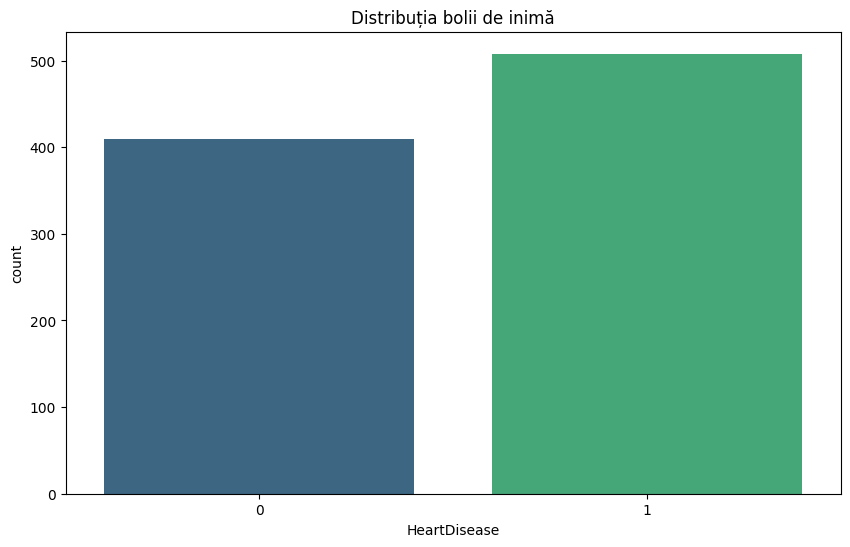

In [5]:
#analiza grafica
plt.figure(figsize=(10,6))
sns.countplot(x='HeartDisease', data=df, palette='viridis')
plt.title('Distribuția bolii de inimă')
plt.show()

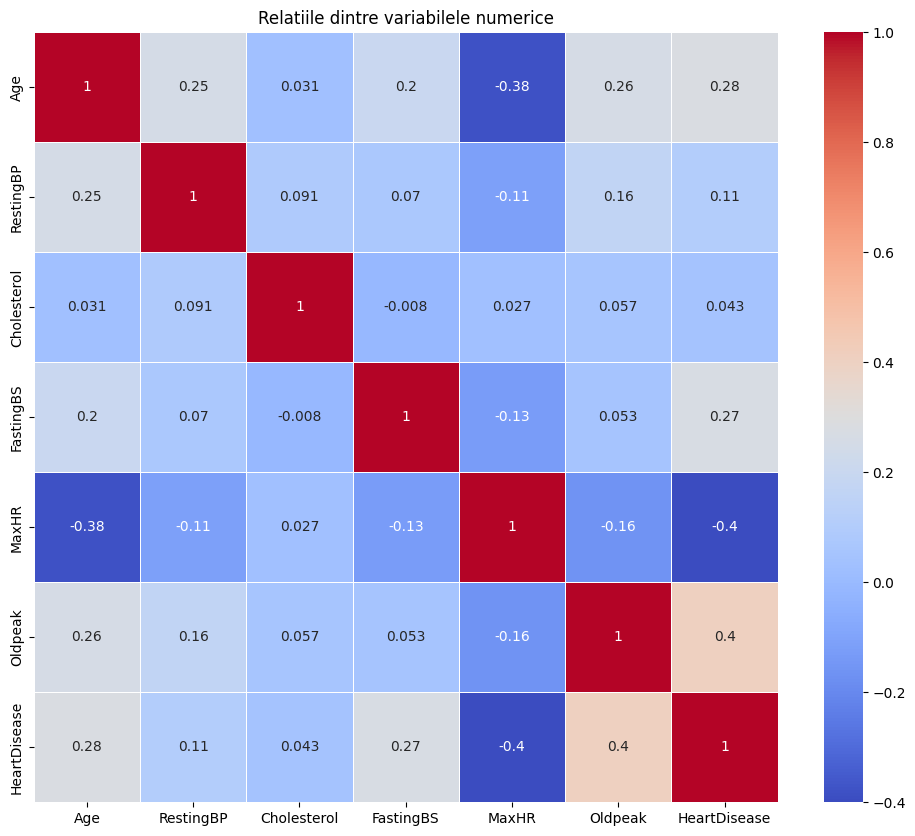

In [6]:
#matrice de corelatie pentru variabilele numerice
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Relatiile dintre variabilele numerice')
plt.show()

In [7]:
df = pd.get_dummies(df, drop_first=True)

_Interpretare EDA_: <br>
&nbsp;&nbsp;Datele sunt bine structurate fara valori nule. Am corectat valorile de 0 de la colesterol folosind mediana, considerandu-le erori de colectare. Graficul distributiei arata un set de date relativ echilibrat, ceea ce faciliteaza antrenarea.

**ANTRENAREA SI COMPARAREA MODELELOR DE BAZA**

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
base_models = {
    "Naïve Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True), # probability=True e necesar pentru ROC-AUC
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Xtreme Gradient Boost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Categorical Boost": CatBoostClassifier(verbose=0),
    "Explainable Boosting Machine": ExplainableBoostingClassifier()
}

In [10]:
results = []
confusion_matrices = {}
for name, model in base_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0] * len(y_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc
    })
    confusion_matrices[name] = cm
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df.to_markdown(index=False))

top_5_models = results_df['Model'].head(5).tolist()


C:\Users\Diana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\xgboost\training.py:200: UserWarning: [17:20:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


| Model                        |   Accuracy |   Precision |   Recall |       F1 |   ROC-AUC |
|:-----------------------------|-----------:|------------:|---------:|---------:|----------:|
| Explainable Boosting Machine |   0.878261 |    0.90625  | 0.878788 | 0.892308 |  0.94496  |
| Categorical Boost            |   0.865217 |    0.891473 | 0.871212 | 0.881226 |  0.936998 |
| Logistic Regression          |   0.865217 |    0.904    | 0.856061 | 0.879377 |  0.932437 |
| Random Forest                |   0.86087  |    0.884615 | 0.871212 | 0.877863 |  0.923122 |
| Naïve Bayes                  |   0.852174 |    0.901639 | 0.833333 | 0.866142 |  0.929267 |
| Xtreme Gradient Boost        |   0.847826 |    0.88189  | 0.848485 | 0.864865 |  0.92633  |
| Decision Tree                |   0.76087  |    0.834783 | 0.727273 | 0.777328 |  0.766698 |
| Support Vector Machine       |   0.682609 |    0.732283 | 0.704545 | 0.718147 |  0.742424 |
| K-Nearest Neighbors          |   0.673913 |    0.731707 | 

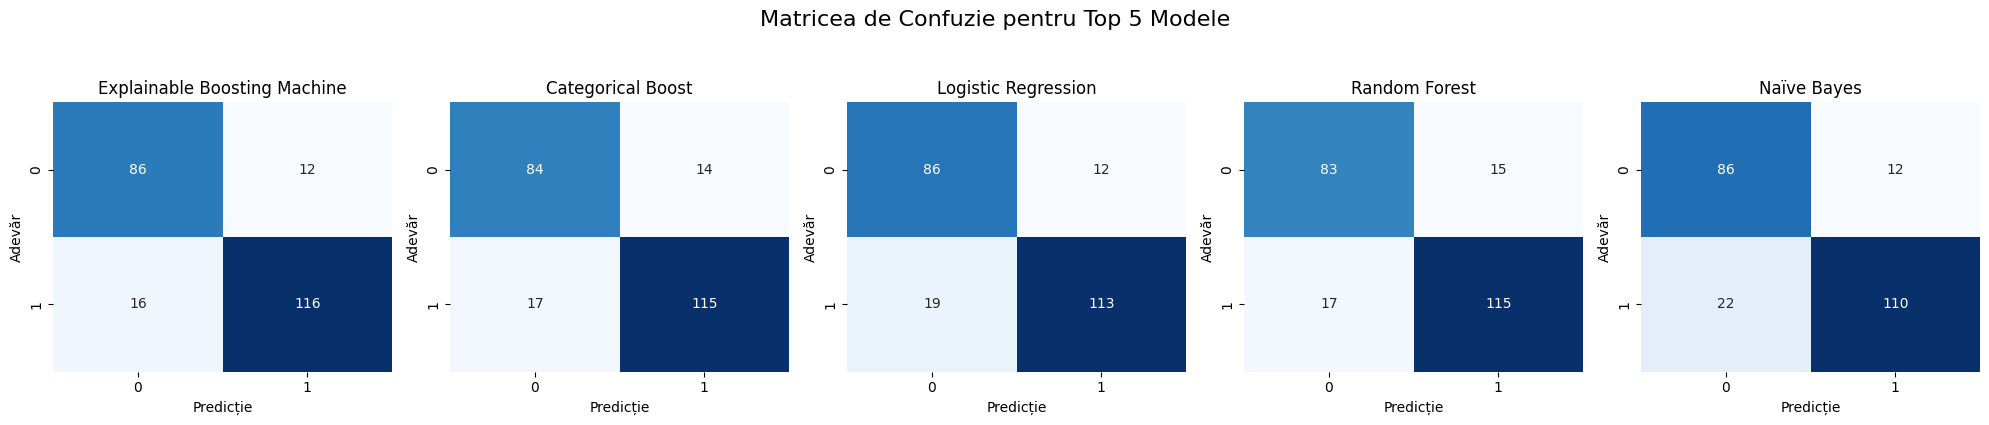

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Matricea de Confuzie pentru Top 5 Modele', fontsize=16, y=1.05)

for i, model_name in enumerate(top_5_models):
    # AICI era problema: am adăugat ax=axes[i] la final!
    sns.heatmap(confusion_matrices[model_name], annot=True, fmt='g', cmap='Blues', cbar=False, ax=axes[i])
    
    axes[i].set_title(model_name)
    axes[i].set_xlabel('Predicție')
    axes[i].set_ylabel('Adevăr')

plt.tight_layout()
plt.show()


_Concluzie modele de baza_:<br>
&nbsp;&nbsp;Analizand tabelul, am identificat ca algoritmii Explainable Boosting Classifier si Random Forest ofera cele mai bune performanete initiale.<br>
&nbsp;&nbsp;Din analiza Matricelor de confuzie pentru top 5 modele, observăm capacitatea algoritmilor de a minimiza fals-negativele (pacienți bolnavi clasificați greșit ca fiind sănătoși), lucru reflectat și în valorile ridicate ale metricii Recall-ul, aspect esențial într-o problemă medicală.


**AJUSTAREA HIPERPARAMETRILOR PENTRU PRIMELE 5 MODELE** 

In [12]:
param_grid_ebm = {
    'learning_rate': [0.01, 0.1],
    'max_bins': [256],
    'interactions': [0, 5]           
}

grid_ebm = GridSearchCV(ExplainableBoostingClassifier(random_state=42), param_grid_ebm, cv=5, scoring='f1', n_jobs=-1)
grid_ebm.fit(X_train, y_train)
print("Best parameters EBM:", grid_ebm.best_params_)

param_grid_rf = {
    'n_estimators': [100, 200],       
    'max_depth': [None, 10, 20],      
    'min_samples_split': [2, 5]       
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best parameters Rain Forest:", grid_rf.best_params_)

param_grid_cb = {
    'iterations': [100, 200],         
    'learning_rate': [0.01, 0.1],     
    'depth': [4, 6]                   
}

grid_cb = GridSearchCV(CatBoostClassifier(verbose=0, random_state=42), param_grid_cb, cv=5, scoring='f1', n_jobs=-1)
grid_cb.fit(X_train, y_train)
print("Best parameters CatBoost:", grid_cb.best_params_)

param_grid_lr = {
    'C': [0.1, 1.0, 10.0],            
    'solver': ['liblinear', 'lbfgs']  
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=10000, random_state=42), param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print("Best parameters Logistic Regression:", grid_lr.best_params_)

param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6] 
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='f1', n_jobs=-1)
grid_nb.fit(X_train, y_train)
print("Best parameters Naive Bayes:", grid_nb.best_params_)

Best parameters EBM: {'interactions': 0, 'learning_rate': 0.01, 'max_bins': 256}
Best parameters Rain Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best parameters CatBoost: {'depth': 6, 'iterations': 200, 'learning_rate': 0.01}
Best parameters Logistic Regression: {'C': 1.0, 'solver': 'lbfgs'}
Best parameters Naive Bayes: {'var_smoothing': 1e-06}


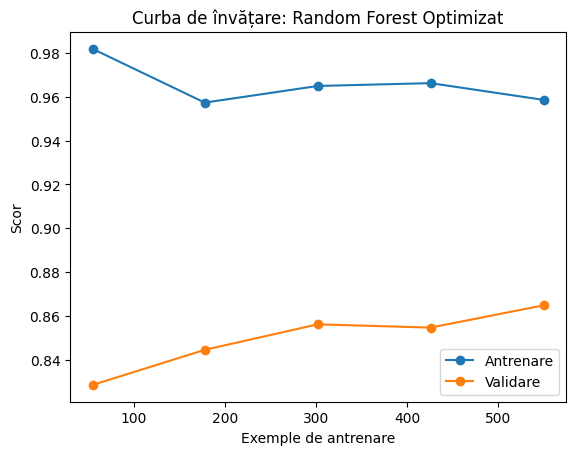

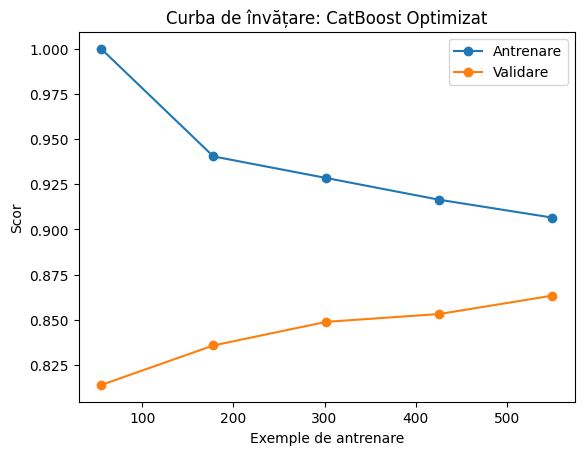

In [ ]:
def plot_learning_curve(estimator, title, X, y):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=5)
    plt.figure()
    plt.title(title)
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Antrenare")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Validare")
    plt.xlabel("Exemple de antrenare")
    plt.ylabel("Scor")
    plt.legend()
    plt.show()

plot_learning_curve(grid_rf.best_estimator_, "Curba de învățare: Random Forest Optimizat", X_train, y_train)
plot_learning_curve(grid_cb.best_estimator_, "Curba de învățare: CatBoost Optimizat", X_train, y_train)
plot_learning_curve(grid_ebm.best_estimator_, "Curba de învățare: EBM Optimizat", X_train, y_train)
plot_learning_curve(grid_lr.best_estimator_, "Curba de învățare: Logistic Regression Optimizat", X_train, y_train)
plot_learning_curve(grid_nb.best_estimator_, "Curba de învățare: Naive Bayes Optimizat", X_train, y_train)